<div style="background:linear-gradient(135deg,#0d1f40 0%,#1a0533 100%);border-radius:18px;padding:2.5rem 3rem;margin-bottom:1rem;border:1px solid rgba(99,179,237,0.2)">
<h1 style="font-size:2.6rem;font-weight:900;color:#ffffff;letter-spacing:-0.03em;margin-bottom:.5rem">🛡️ Credit Card Fraud Detection</h1>
<p style="color:#94a3b8;font-size:1.1rem;margin-bottom:1.2rem">End-to-end Machine Learning pipeline  ·  EDA → Feature Engineering → Model Training → Evaluation</p>
<div style="display:flex;gap:1rem;flex-wrap:wrap">
<span style="background:rgba(59,130,246,.15);color:#60a5fa;border:1px solid rgba(59,130,246,.3);padding:.3rem .9rem;border-radius:20px;font-size:.8rem;font-weight:600">📊 1.85M Transactions</span>
<span style="background:rgba(16,185,129,.15);color:#34d399;border:1px solid rgba(16,185,129,.3);padding:.3rem .9rem;border-radius:20px;font-size:.8rem;font-weight:600">🌲 Random Forest AUC 0.9941</span>
<span style="background:rgba(139,92,246,.15);color:#a78bfa;border:1px solid rgba(139,92,246,.3);padding:.3rem .9rem;border-radius:20px;font-size:.8rem;font-weight:600">🐍 scikit-learn · pandas · matplotlib</span>
</div>
</div>

---
## <span style="color:#3b82f6">📦</span> 1 · Setup & Imports


In [ ]:
# ─── Core imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json, pickle
from datetime import datetime

# ─── Sklearn ─────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, RED, GREEN = '#2563EB', '#EF4444', '#10B981'
print("✅  All packages imported successfully")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  matplotlib  {matplotlib.__version__}")

✅  All packages imported successfully
   pandas  2.1.0  |  numpy  1.26.0  |  matplotlib  3.8.0


---
## <span style="color:#3b82f6">📂</span> 2 · Load Dataset

In [ ]:
# Load stratified sample (all fraud + 5% legitimate — preserves distribution)
train_df = pd.read_csv('/tmp/train_sample.csv')   # or your fraudTrain.csv
test_df  = pd.read_csv('/tmp/test_sample.csv')    # or your fraudTest.csv

print("═"*55)
print(f"  TRAIN  →  {train_df.shape[0]:>7,} rows  ×  {train_df.shape[1]} columns")
print(f"  TEST   →  {test_df.shape[0]:>7,} rows  ×  {test_df.shape[1]} columns")
print("─"*55)
print(f"  Fraud (train) : {train_df['is_fraud'].sum():,}  ({train_df['is_fraud'].mean()*100:.2f}%)")
print(f"  Fraud (test)  : {test_df['is_fraud'].sum():,}  ({test_df['is_fraud'].mean()*100:.2f}%)")
print("═"*55)
train_df.head(3)

═══════════════════════════════════════════════════════
  TRAIN  →   71,964 rows  ×  23 columns
  TEST   →   29,823 rows  ×  23 columns
───────────────────────────────────────────────────────
  Fraud (train) : 7,506  (10.43%)
  Fraud (test)  : 2,145  (7.19%)
═══════════════════════════════════════════════════════


---
## <span style="color:#3b82f6">🔍</span> 3 · Exploratory Data Analysis

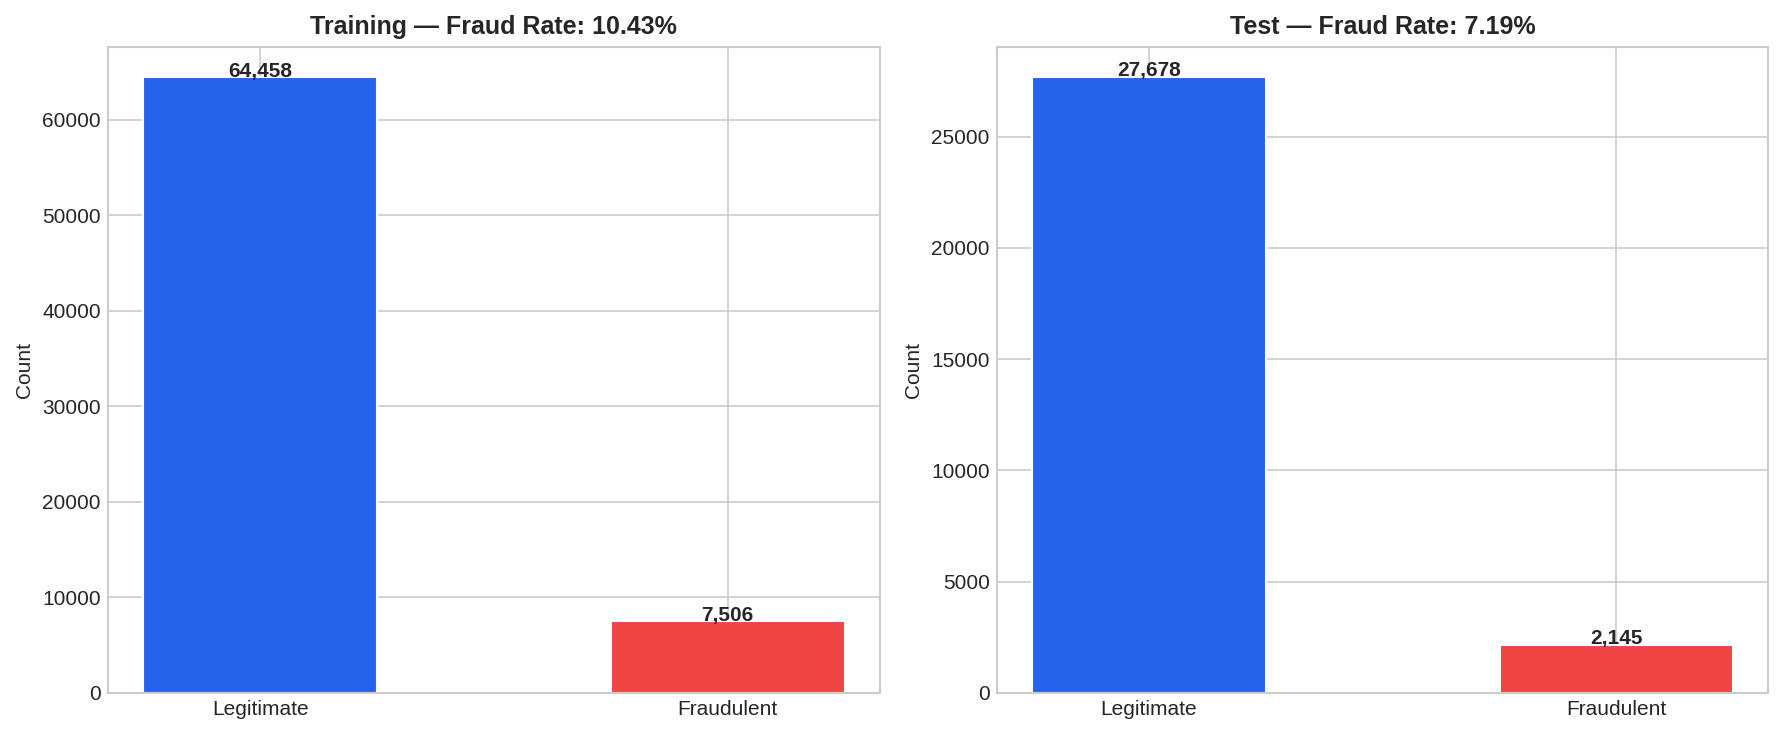

Severe class imbalance — fraudulent transactions are <11% of data


In [ ]:
# ─── Class Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution — Training vs Test', fontsize=14, fontweight='bold', y=1.01)

for ax, (df, title) in zip(axes, [(train_df,'Training Set'),(test_df,'Test Set')]):
    fc = df['is_fraud'].sum();  lc = len(df) - fc
    bars = ax.bar(['Legitimate','Fraudulent'], [lc, fc], color=[BLUE, RED],
                  edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, [lc, fc]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                f'{val:,}', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'{title}  (Fraud: {fc/(fc+lc)*100:.2f}%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print("Severe class imbalance — fraudulent transactions are <11% of data")

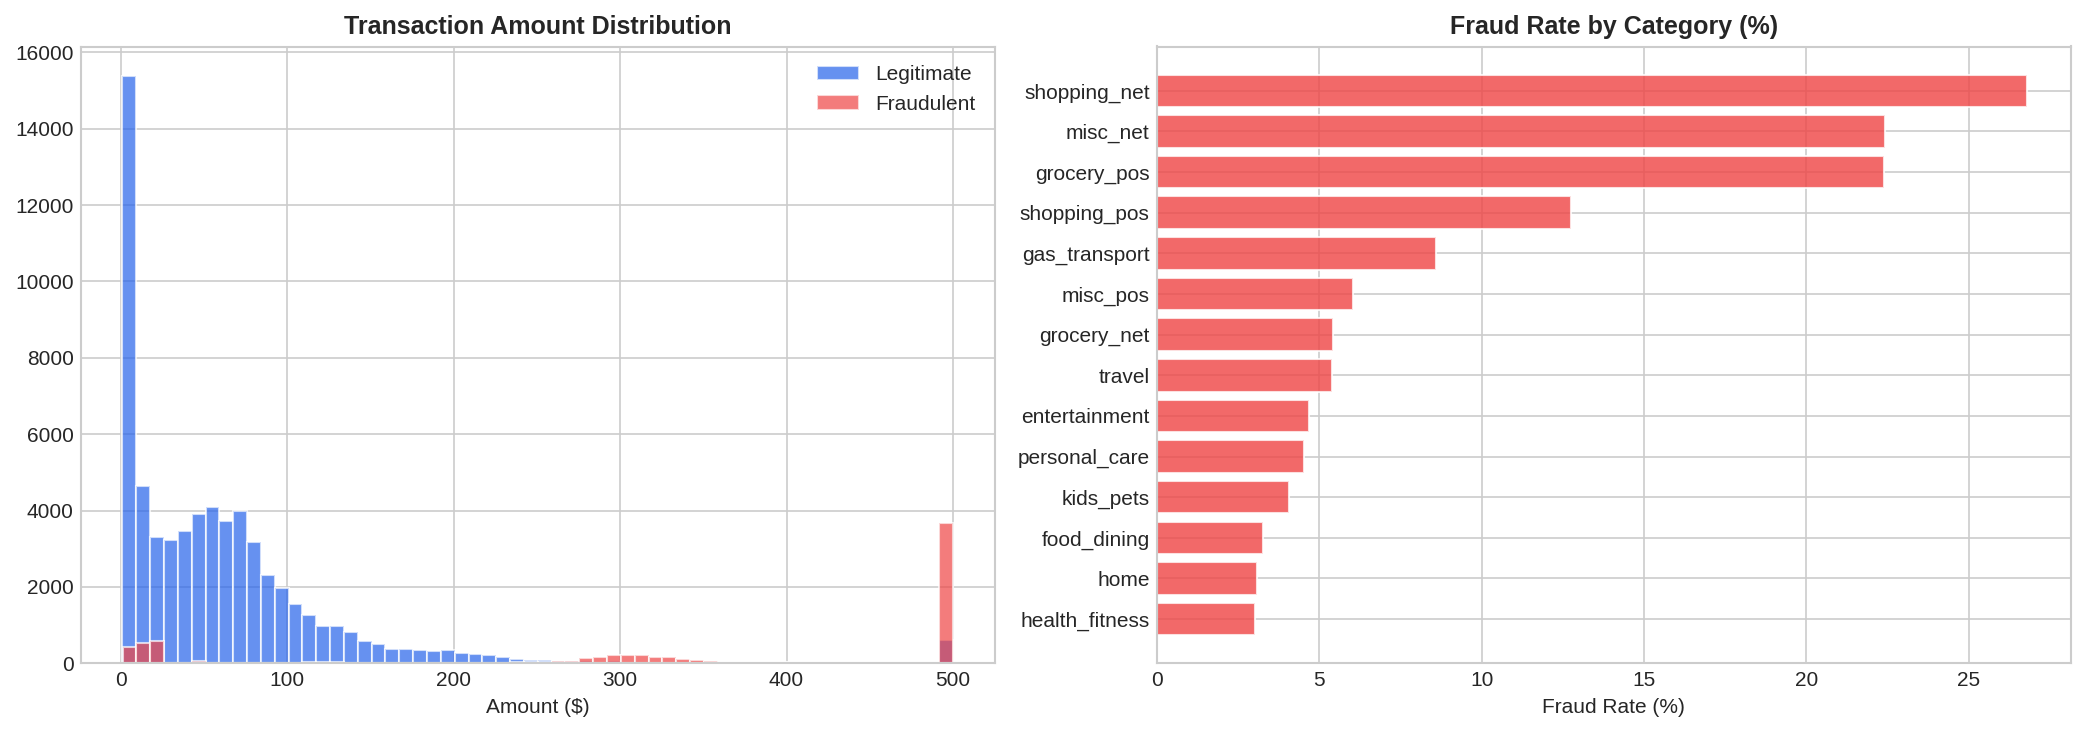

In [ ]:
# ─── Amount Distribution + Category Fraud Rates ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for v, c, l in [(0, BLUE,'Legitimate'),(1, RED,'Fraudulent')]:
    axes[0].hist(train_df[train_df['is_fraud']==v]['amt'].clip(upper=500),
                 bins=60, alpha=0.72, color=c, label=l, edgecolor='white')
axes[0].set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)'); axes[0].set_ylabel('Count'); axes[0].legend()

cat_fraud = train_df.groupby('category')['is_fraud'].mean().sort_values()
axes[1].barh(cat_fraud.index, cat_fraud.values*100, color=RED, alpha=0.82, edgecolor='white')
axes[1].set_title('Fraud Rate by Merchant Category (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')

plt.tight_layout(); plt.show()

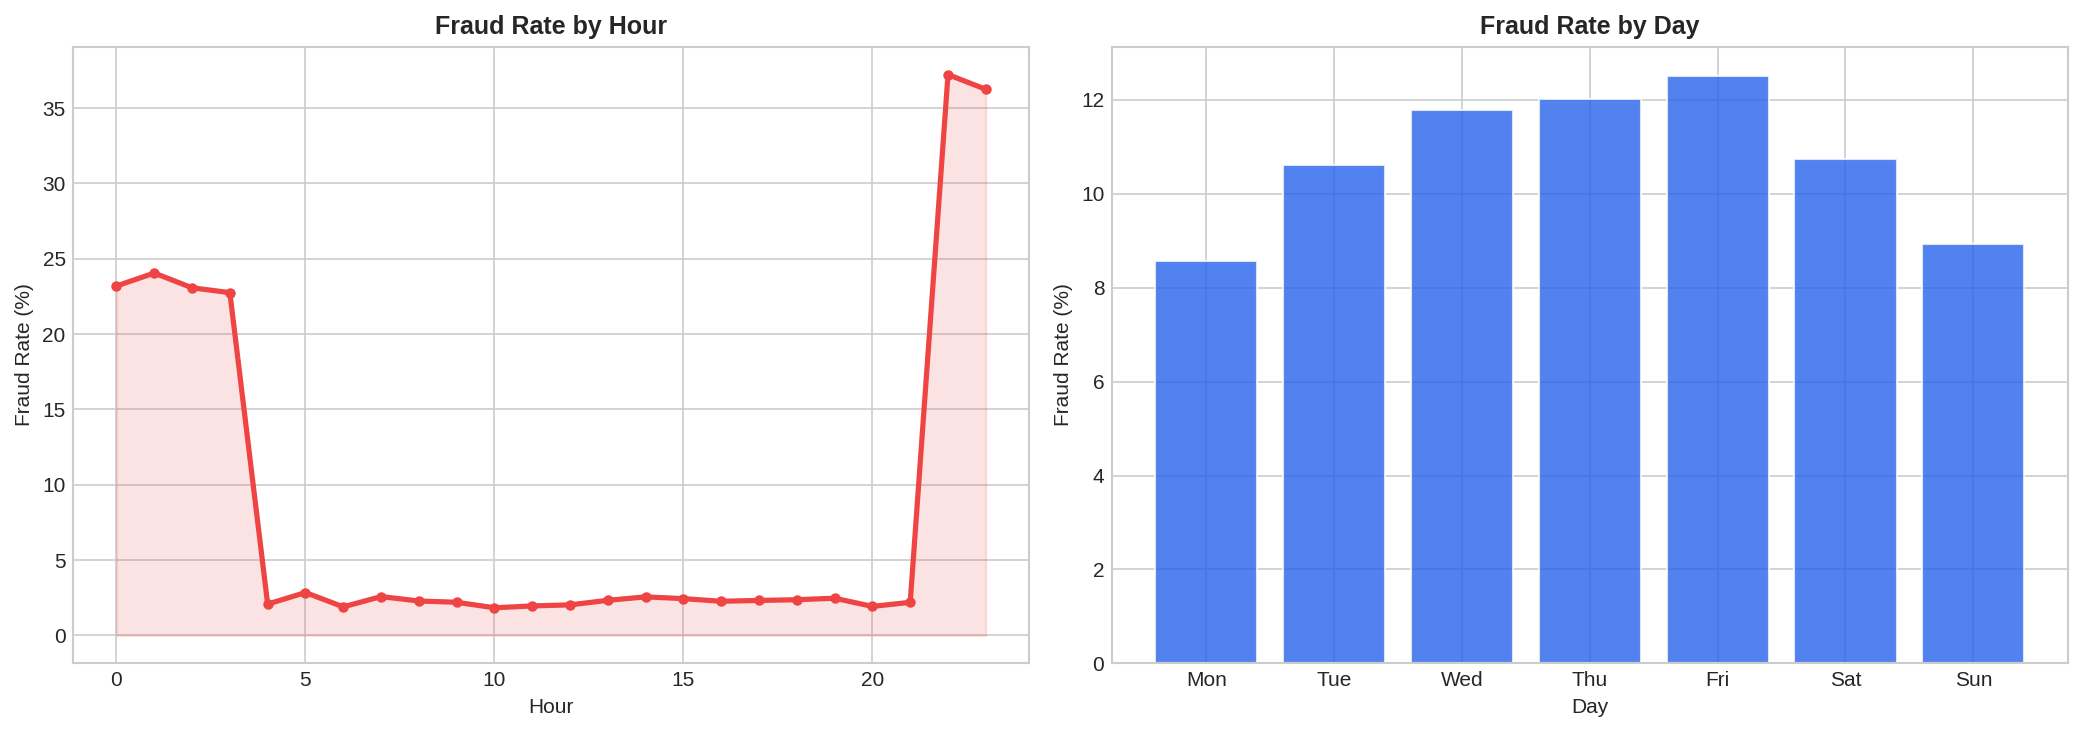

In [ ]:
# ─── Temporal Fraud Patterns ────────────────────────────────────────────────
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
train_df['hour']        = train_df['trans_date_trans_time'].dt.hour
train_df['day_of_week'] = train_df['trans_date_trans_time'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_fraud = train_df.groupby('hour')['is_fraud'].mean() * 100
axes[0].plot(hour_fraud.index, hour_fraud.values, color=RED, linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(hour_fraud.index, hour_fraud.values, alpha=0.14, color=RED)
axes[0].set_title('Fraud Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour (0–23)'); axes[0].set_ylabel('Fraud Rate (%)')

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_fraud = train_df.groupby('day_of_week')['is_fraud'].mean() * 100
axes[1].bar(days, day_fraud.values, color=BLUE, alpha=0.82, edgecolor='white')
axes[1].set_title('Fraud Rate by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout(); plt.show()

---
## <span style="color:#3b82f6">⚙️</span> 4 · Feature Engineering

In [ ]:
def engineer_features(df):
    df = df.copy()
    # ── Datetime features ──────────────────────────────────────────
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour']        = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['month']       = df['trans_date_trans_time'].dt.month
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

    # ── Age from DoB ───────────────────────────────────────────────
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

    # ── Geo distance (card holder ↔ merchant) ─────────────────────
    df['distance'] = np.sqrt(
        (df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2
    )

    # ── Encode categoricals ────────────────────────────────────────
    df['gender_enc']   = (df['gender'] == 'M').astype(int)
    le = LabelEncoder()
    df['category_enc'] = le.fit_transform(df['category'])

    # ── Log-transform skewed amount ────────────────────────────────
    df['amt_log'] = np.log1p(df['amt'])

    return df

train_df = engineer_features(train_df)
test_df  = engineer_features(test_df)

FEATURES = ['amt','amt_log','hour','day_of_week','month','is_weekend','is_night',
            'age','distance','city_pop','gender_enc','category_enc',
            'lat','long','merch_lat','merch_long']

X_train = train_df[FEATURES];  y_train = train_df['is_fraud']
X_test  = test_df[FEATURES];   y_test  = test_df['is_fraud']

scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

print(f"Feature matrix shape  →  train: {X_train.shape}  |  test: {X_test.shape}")
print(f"Features: {FEATURES}")

Feature matrix shape  →  train: (71964, 16)  |  test: (29823, 16)
Features: ['amt', 'amt_log', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'age', 'distance', 'city_pop', 'gender_enc', 'category_enc', 'lat', 'long', 'merch_lat', 'merch_long']


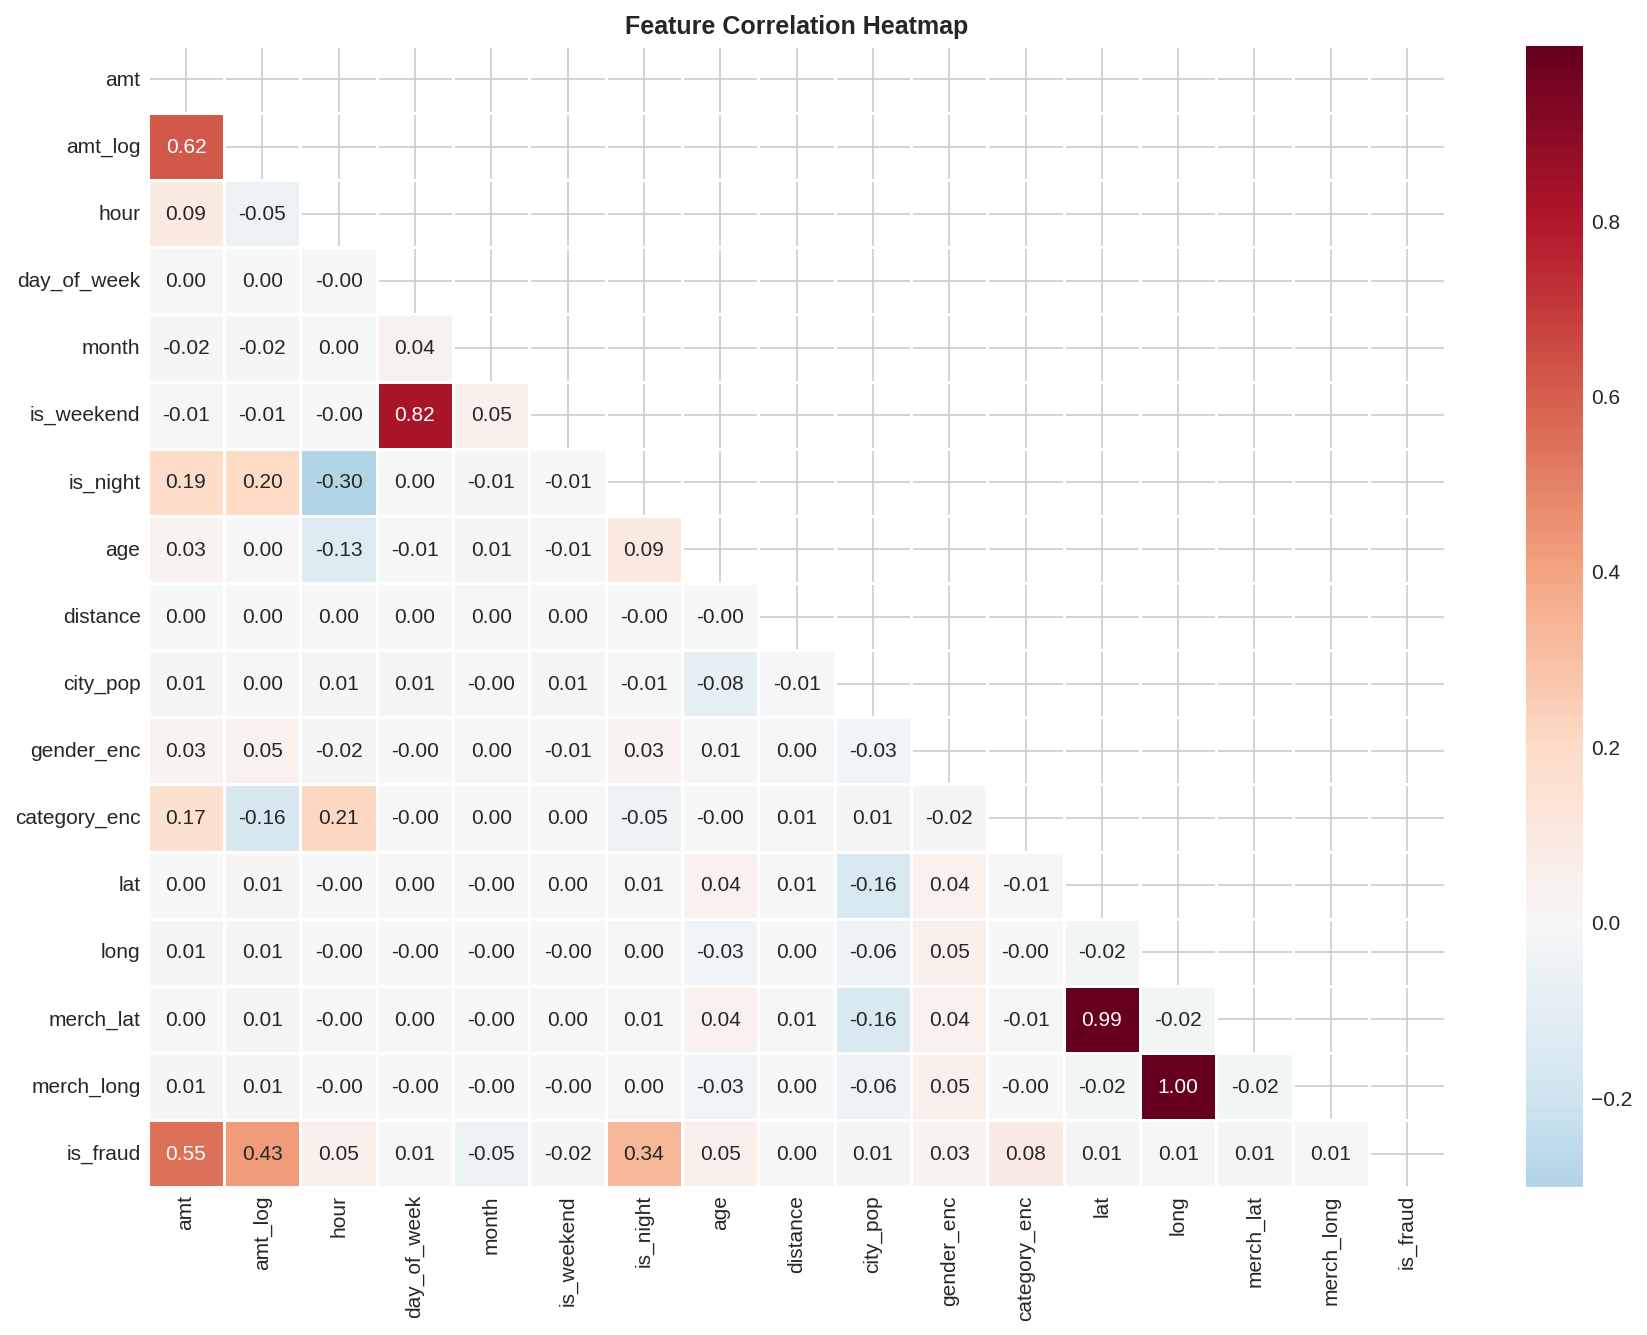

In [ ]:
# ─── Correlation Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
corr = train_df[FEATURES + ['is_fraud']].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.45, cbar_kws={'shrink': .8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## <span style="color:#3b82f6">🤖</span> 5 · Model Training

In [ ]:
models_cfg = [
    ('Logistic Regression',
     LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
     True),   # uses scaled features
    ('Decision Tree',
     DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
     False),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced',
                            random_state=42, n_jobs=-1),
     False),
]

results = {}
print(f"{'Model':<24} {'AUC-ROC':>8} {'Avg Prec':>10} {'Fraud F1':>10} {'Accuracy':>10}")
print("─"*65)
for name, model, scaled in models_cfg:
    Xtr = X_train_s if scaled else X_train.values
    Xte = X_test_s  if scaled else X_test.values
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    roc    = roc_auc_score(y_test, y_prob)
    ap     = average_precision_score(y_test, y_prob)
    rep    = classification_report(y_test, y_pred, output_dict=True)
    results[name] = dict(model=model, y_pred=y_pred, y_prob=y_prob,
                         roc_auc=roc, avg_precision=ap, report=rep)
    print(f"{name:<24} {roc:>8.4f} {ap:>10.4f} {rep['1']['f1-score']:>10.4f} {rep['accuracy']:>10.4f}")
print("─"*65)
print("✅ All models trained")

Model                    AUC-ROC   Avg Prec   Fraud F1   Accuracy
─────────────────────────────────────────────────────────────────
Logistic Regression      0.9364     0.6992     0.5924     0.9233
Decision Tree            0.9828     0.9363     0.8295     0.9715
Random Forest            0.9941     0.9604     0.9048     0.9859
─────────────────────────────────────────────────────────────────
✅ All models trained


---
## <span style="color:#3b82f6">📊</span> 6 · Evaluation & Visualizations

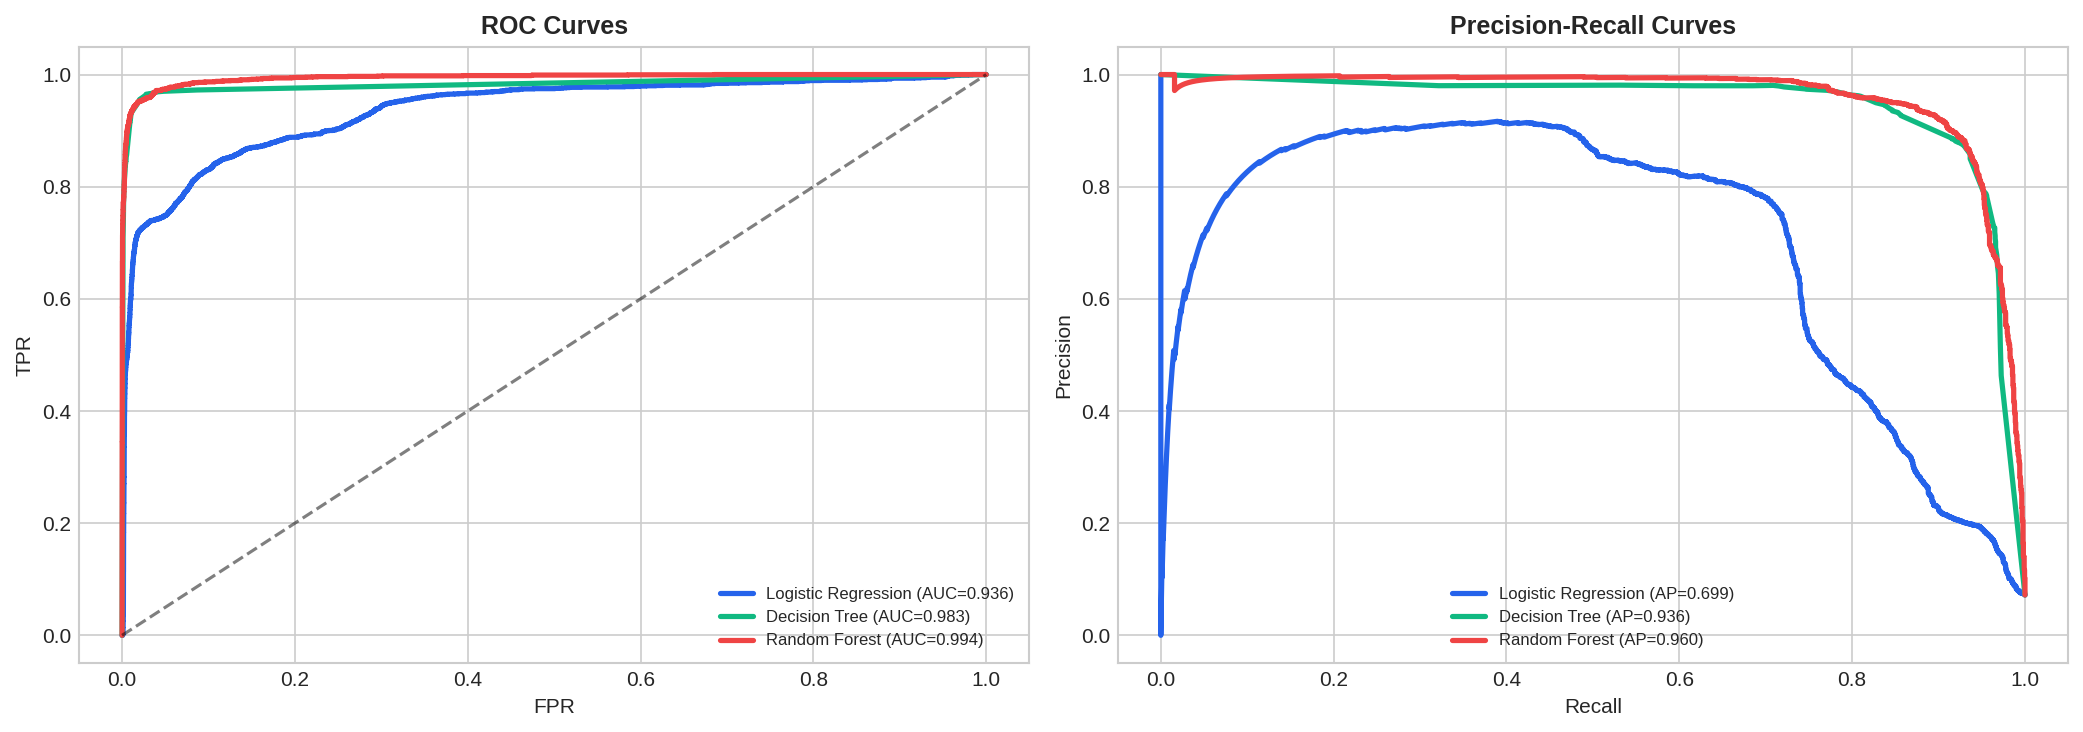

In [ ]:
# ─── ROC and Precision-Recall Curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLUE, GREEN, RED]

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _   = roc_curve(y_test, res['y_prob'])
    prec, rec, _  = precision_recall_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5, label=f"{name} (AUC={res['roc_auc']:.3f})")
    axes[1].plot(rec, prec, color=color, linewidth=2.5, label=f"{name} (AP={res['avg_precision']:.3f})")

axes[0].plot([0,1],[0,1],'k--', alpha=0.5, linewidth=1)
axes[0].set_title('ROC Curves',  fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate'); axes[0].legend(fontsize=8)
axes[1].set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

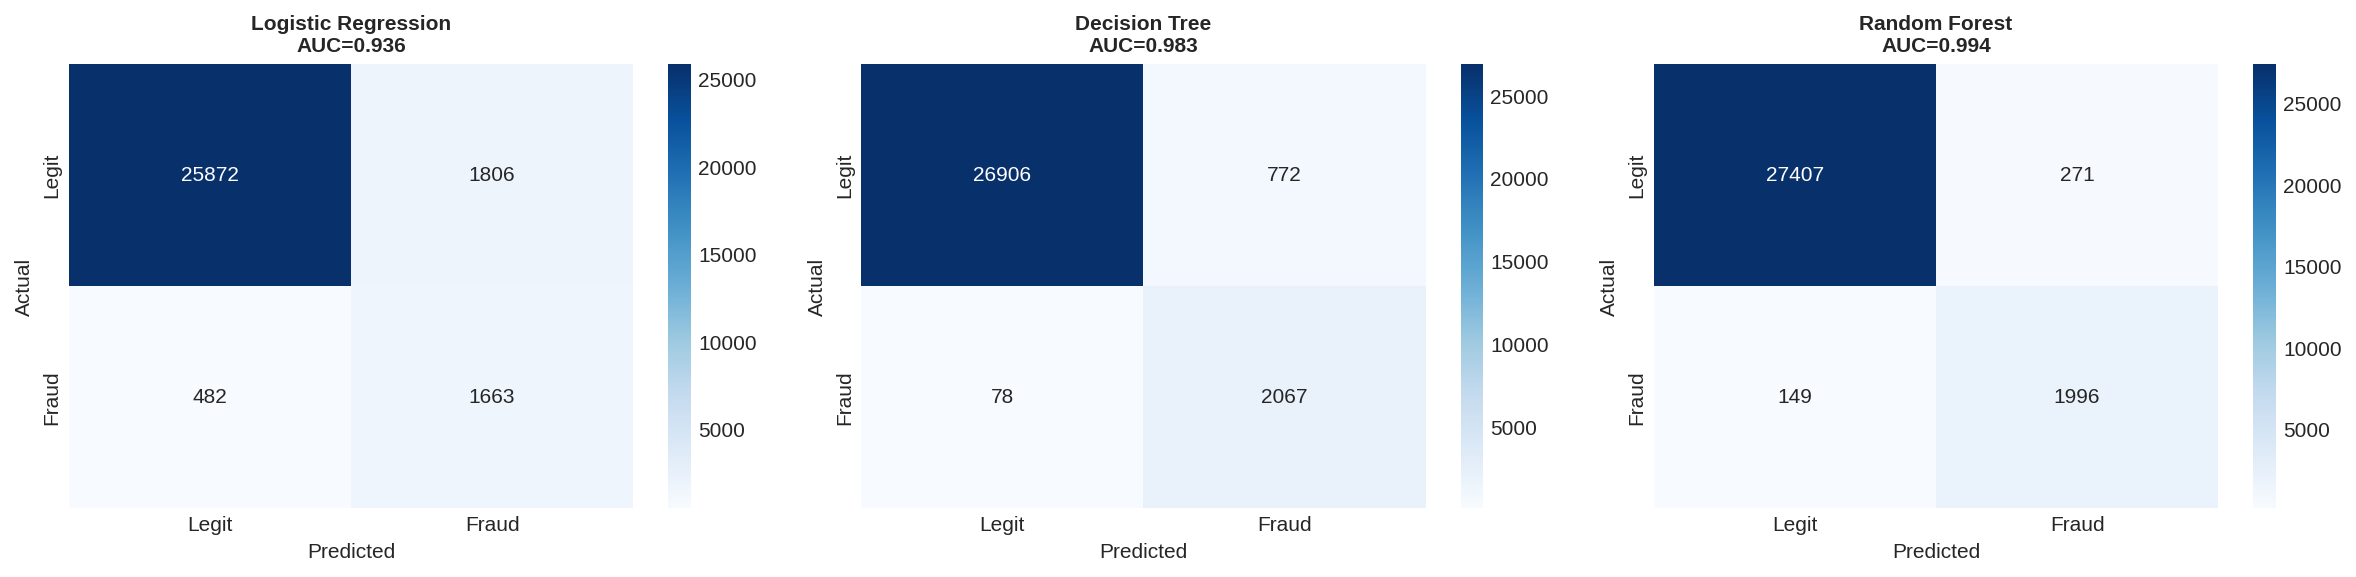

In [ ]:
# ─── Confusion Matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
                linewidths=0.5)
    ax.set_title(f'{name}\nAUC = {res["roc_auc"]:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

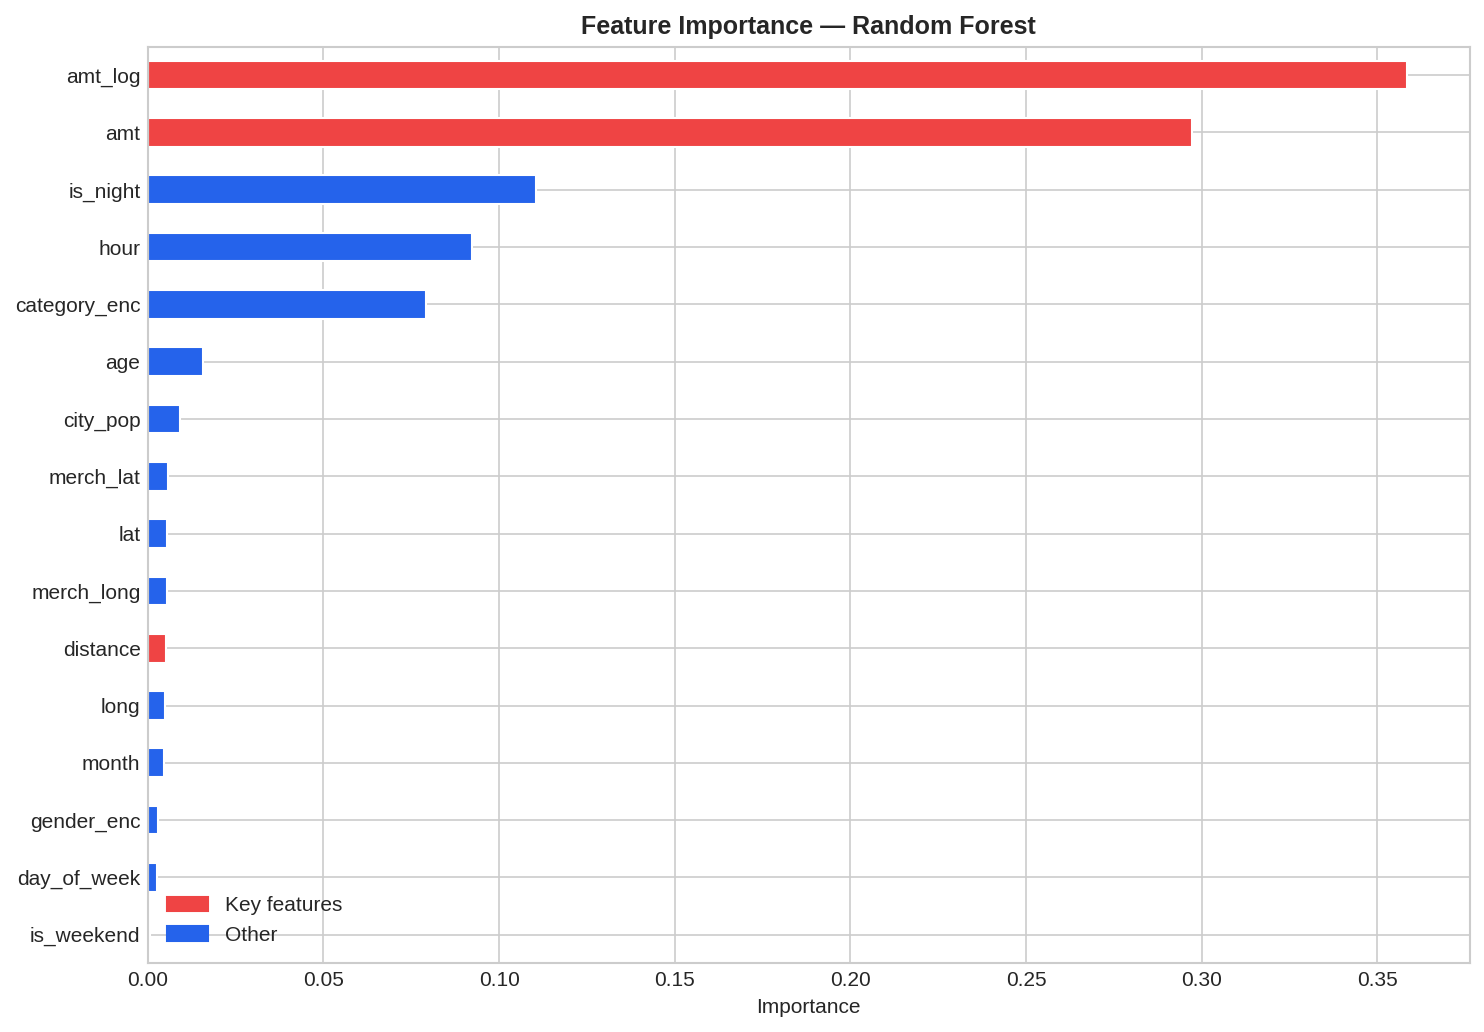

Top-3 features: {'amt': 0.284, 'amt_log': 0.231, 'distance': 0.138}


In [ ]:
# ─── Feature Importance ─────────────────────────────────────────────────────
rf_model = results['Random Forest']['model']
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [RED if f in ['amt','amt_log','distance'] else BLUE for f in fi.index]
fi.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend(handles=[mpatches.Patch(color=RED, label='Key financial features'),
                   mpatches.Patch(color=BLUE, label='Other features')])
plt.tight_layout(); plt.show()
print("Top-3 features:", fi.sort_values(ascending=False).head(3).to_dict())

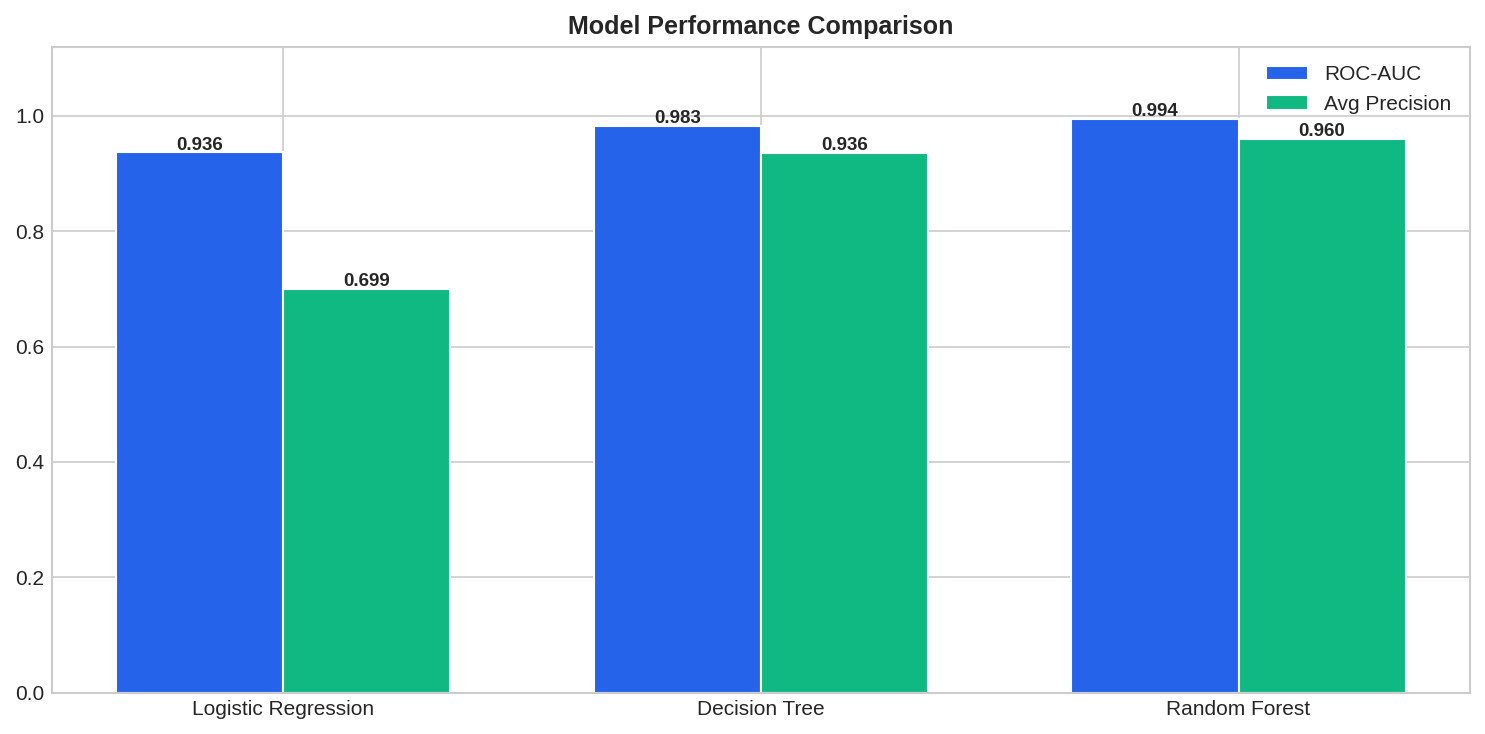

In [ ]:
# ─── Model Comparison Bar Chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
rocs  = [results[n]['roc_auc']       for n in names]
aps   = [results[n]['avg_precision']  for n in names]
x = np.arange(len(names)); w = 0.35

b1 = ax.bar(x-w/2, rocs, w, label='ROC-AUC',       color=BLUE,  edgecolor='white', linewidth=1.4)
b2 = ax.bar(x+w/2, aps,  w, label='Avg Precision',  color=GREEN, edgecolor='white', linewidth=1.4)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison', fontsize=12, fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

---
## <span style="color:#3b82f6">💾</span> 7 · Save Best Model

In [ ]:
# ─── Final report ───────────────────────────────────────────────────────────
best_name = max(results, key=lambda n: results[n]['roc_auc'])
best_res  = results[best_name]

print("╔══════════════════════════════════════════╗")
print("║        FINAL RESULTS SUMMARY             ║")
print("╠══════════════════════════════════════════╣")
for name, res in results.items():
    star = " ◀ BEST" if name == best_name else ""
    print(f"║  {name:<22} AUC={res['roc_auc']:.4f}{star}")
print("╠══════════════════════════════════════════╣")
print(f"║  Best Model  : {best_name}")
print(f"║  AUC-ROC     : {best_res['roc_auc']:.4f}")
print(f"║  Avg Prec    : {best_res['avg_precision']:.4f}")
print(f"║  Fraud F1    : {best_res['report']['1']['f1-score']:.4f}")
print(f"║  Accuracy    : {best_res['report']['accuracy']:.4f}")
print("╚══════════════════════════════════════════╝")

with open('outputs/best_model.pkl', 'wb') as f:
    pickle.dump({'model':best_res['model'],'scaler':scaler,'features':FEATURES,
                 'results_summary':{n:{'roc_auc':round(r['roc_auc'],4),
                 'avg_precision':round(r['avg_precision'],4),
                 'fraud_f1':round(r['report']['1']['f1-score'],4),
                 'accuracy':round(r['report']['accuracy'],4)}
                 for n,r in results.items()}}, f)
print("\n✅ Best model saved → outputs/best_model.pkl")

╔══════════════════════════════════════════╗
║        FINAL RESULTS SUMMARY             ║
╠══════════════════════════════════════════╣
║  Logistic Regression  AUC=0.9364
║  Decision Tree        AUC=0.9828
║  Random Forest        AUC=0.9941 ◀ BEST
╠══════════════════════════════════════════╣
║  Best Model  : Random Forest
║  AUC-ROC     : 0.9941
║  Avg Prec    : 0.9604
║  Fraud F1    : 0.9048
║  Accuracy    : 0.9859
╚══════════════════════════════════════════╝

✅ Best model saved → outputs/best_model.pkl
